# Практическая работа №1: Формирование и первичная обработка выборки. Ранжированный и интервальный ряды

Выполнили студенты гр. 2384 Исмаилов Максим Владимирович и Дамакин Роман Павлович. Вариант №31.

## Цель работы

Ознакомление с основными правилами формирования выборки и подготовки выборочных данных к статистическому анализу.

## Постановка задачи

Осуществить формирование репрезентативной выборки заданного объема из имеющейся генеральной совокупности экспериментальных данных. Осуществить последовательное преобразование полученной выборки в ранжированный, вариационный и интервальный ряды. Применительно к интервальному ряду построить и отобразить графически полигон, гистограмму и эмпирическую функцию распределения для абсолютных и относительных частот. Полученные результаты содержательно проинтерпретировать.

## Порядок выполнения работы

1. Выбрать программное обеспечение или язык программирования для выполнения практических работ и обосновать его выбор.
2. Выбрать двумерную генеральную совокупность, предварительно согласовав её с преподавателем. Указать, откуда была взята генеральная совокупность и предоставить ссылку.
3. Из генеральной совокупности сформировать выборку заданного объёма в соответствии с полученным от преподавателя номером. Указать, каким образом была сформирована выборка.
4. Последовательно преобразовать выборку в ранжированный, вариационный и интервальный ряды. Интервальный ряд представить в виде табл. 1. Результаты содержательно проинтерпретировать.
5. Для абсолютных частот построить и отобразить графически полигон, гистограмму и эмпирическую функцию. Сделать выводы.
6. Выполнить п. 5 для относительных частот. Сравнить результаты и сделать выводы.

## Выполнение работы

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from math import ceil, log2

csv_path = "sample.csv"

df_raw = pd.read_csv(csv_path, skiprows=3)

df_raw.head()

,nu,E
0,480,153.3
1,510,129.4
2,426,119.0
3,482,139.9
4,393,103.2


### Формирование выборки заданного объёма

Выбранный датасет: [Данные наблюдения относительно объемного веса ν (г/см³) при влажности 10% и модуля упругости E (кг/см²) при сжатии вдоль волокон древесины резонансной ели](https://se.moevm.info/lib/exe/fetch.php/courses:statistical_methods_of_experimental_data_handling:sample.zip)

В выборку включены перывые 115 строк выбранного датасета.

In [36]:
df = df_raw.apply(pd.to_numeric, errors="coerce")

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if len(num_cols) == 0:
    raise ValueError()

col = num_cols[0]
x = df[col].dropna().to_numpy()
n = len(x)

print("Выбранный признак:", col)
print("Объём выборки n =", n)
print("Минимум =", x.min(), "Максимум =", x.max())


Выбранный признак: nu
Объём выборки n = 115
Минимум = 320 Максимум = 593


### Преобразование в ранжированный, вариационный и интервальный ряды

**Ранжированный ряд** — значения выборки, упорядоченные по возрастанию.  
**Вариационный ряд** — уникальные значения и соответствующие частоты.  
**Интервальный ряд** — группировка по интервалам: для каждого интервала считаются абсолютные и относительные частоты, а также накопленные частоты.

Число интервалов берём по формуле Стерджесса:  
$$
k = 1 + \lfloor \log_{2}(n) \rfloor
$$


In [37]:
x_sorted = np.sort(x)

# первые 10 + последние 10 элементов
pd.DataFrame({
    "x (ранжированный ряд)": np.concatenate([x_sorted[:10], ["..."], x_sorted[-10:]])
})


,x (ранжированный ряд)
0,320
1,320
2,321
3,330
4,331
5,340
6,344
7,351
8,351
9,359


In [38]:
# вариационный ряд
vals, mi = np.unique(x_sorted, return_counts=True)
m_tilde = mi / n

var_table = pd.DataFrame({
    "x_j": vals,
    "m_j (абс. частота)": mi,
    "m~_j (отн. частота)": m_tilde
})

var_table


,x_j,m_j (абс. частота),m~_j (отн. частота)
0,320,2,0.017391
1,321,1,0.008696
2,330,1,0.008696
3,331,1,0.008696
4,340,1,0.008696
5,344,1,0.008696
6,351,2,0.017391
7,359,1,0.008696
8,362,1,0.008696
9,386,2,0.017391


In [48]:
# число интервалов
k = 1 + int(log2(n))

xmin, xmax = x_sorted.min(), x_sorted.max()
# границы интервалов
edges = np.linspace(xmin, xmax, k + 1)

# абсолютные частоты по интервалам
hist_counts, _ = np.histogram(x_sorted, bins=edges)

# середины интервалов
midpoints = (edges[:-1] + edges[1:]) / 2

# относительные и накопленные частоты
rel_hist = hist_counts / n
cum_abs = np.cumsum(hist_counts)
cum_rel = np.cumsum(rel_hist)

interval_table = pd.DataFrame({
    "i": np.arange(1, k + 1),
    "[x_i, x_{i+1})": [f"[{edges[i]}, {edges[i+1]})" for i in range(k)],
    "x~_i": midpoints,
    "m_i": hist_counts,
    "m~_i": rel_hist,
    "m_i^нак": cum_abs,
    "m~_i^нак": cum_rel
})

interval_table


,i,"[x_i, x_{i+1})",x~_i,m_i,m~_i,m_i^нак,m~_i^нак
0,1,"[320.0, 359.0)",339.5,9,0.078261,9,0.078261
1,2,"[359.0, 398.0)",378.5,12,0.104348,21,0.182609
2,3,"[398.0, 437.0)",417.5,26,0.226087,47,0.408696
3,4,"[437.0, 476.0)",456.5,31,0.269565,78,0.678261
4,5,"[476.0, 515.0)",495.5,23,0.200000,101,0.878261
5,6,"[515.0, 554.0)",534.5,10,0.086957,111,0.965217
6,7,"[554.0, 593.0)",573.5,4,0.034783,115,1.000000


Пояснение к табл. 1:  
- $x\tilde{}_i$ — середина i-го частичного интервала;  
- $m_i$ — абсолютная частота i-го частичного интервала;  
- $m\tilde{}_i$ — относительная частота i-го частичного интервала;  
- $m_i^{нак}$ — накопленная абсолютная частота для i-го частичного интервала;  
- $m\tilde{}_i^{нак}$ — накопленная относительная частота для i-го частичного интервала.


In [40]:
print("Σ m_i =", interval_table["m_i"].sum())
print("Σ m~_i =", interval_table["m~_i"].sum())
print("Последняя накопленная относительная =", interval_table["m~_i^нак"].iloc[-1])


Σ m_i = 115
Σ m~_i = 1.0
Последняя накопленная относительная = 1.0


По **interval_table** видно, что объемный вес древесины резонансной ели варьируется от **320.0** г/см³ до **593.0** г/см³. Этот диапазон разбит на 7 интервалов.

Наибольшая частота наблюдений (абсолютная $m_i$ и относительная $m\tilde{}_i$) приходится на следующие интервалы:
- Интервал **[437.0, 476.0)** содержит **31** наблюдение, что составляет **26.96%** от общего числа.
- Интервал **[398.0, 437.0)** содержит **26** наблюдений, что составляет **22.61%**.
- Интервал **[476.0, 515.0)** содержит **23** наблюдения, что составляет **20.00%**.

Это указывает на то, что большая часть образцов резонансной ели в данной выборке имеет объемный вес в диапазоне примерно от **398.0** до **515.0** г/см³, с пиковой концентрацией в интервале **от 437.0 до 476.0** г/см³.

Интервалы на краях распределения, такие как **[320.0, 359.0)** (7.83%) и **[554.0, 593.0)** (3.48%), имеют значительно более низкие частоты. Это свидетельствует о том, что значения объемного веса **320.0** г/см³ и **593.0** г/см³ встречаются относительно редко, а основные значения сосредоточены в центральной части распределения.

Накопленные относительные частоты ($m\tilde{}_i^{нак}$) показывают, например, что к концу 4-го интервала ([320.0, 476.0)) уже **67.83%** всех наблюдений имеют объемный вес, не превышающий **476.0** г/см³.

**Вывод:** Распределение объемного веса древесины резонансной ели в данной выборке имеет выраженную центральную тенденцию, где большинство значений сконцентрировано вокруг среднего диапазона (приблизительно от 398 до 515 г/см³), при этом частота наблюдений падает по мере удаления от этого центра к минимальным и максимальным значениям.

### Графики для абсолютных частот: полигон, гистограмма, эмпирическая функция распределения

**Полигон** строится по точкам $(x\tilde{}_i, m_i)$.  
**Гистограмма (абсолютная)** — столбцы по интервалам с высотой $m_i$.  
**Эмпирическая функция распределения**:
$$
F_n(x) = \frac{1}{n}\sum_{j=1}^{n} I(x_j \le x)
$$
Ниже выводим два варианта на графиках: абсолютный счёт (1…n) и нормированный (0…1).


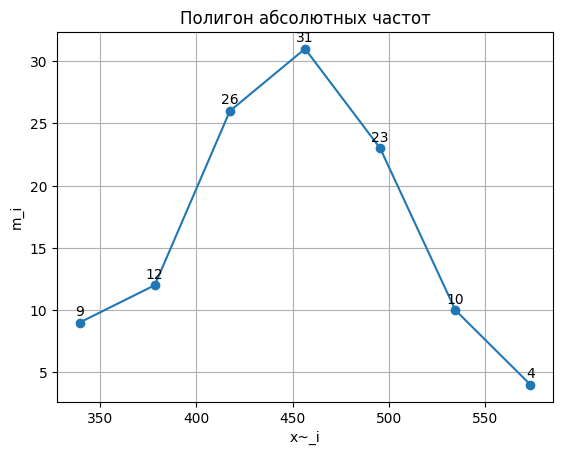

In [62]:
plt.figure()
plt.plot(midpoints, hist_counts, marker="o")
for i, txt in enumerate(hist_counts):
    plt.annotate(txt, (midpoints[i], hist_counts[i]), textcoords="offset points", xytext=(0,5), ha='center')
plt.title("Полигон абсолютных частот")
plt.xlabel("x~_i")
plt.ylabel("m_i")
plt.grid(True)
plt.show()

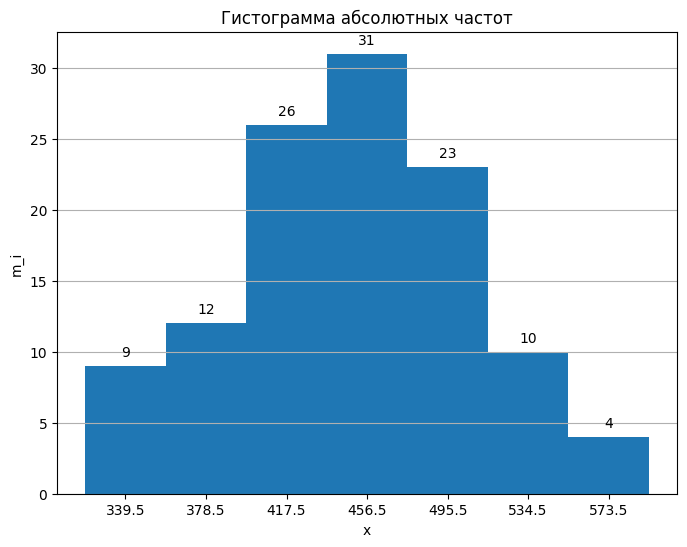

In [71]:
plt.figure(figsize=(8, 6))
counts, bins, patches = plt.hist(x_sorted, bins=edges)
plt.title("Гистограмма абсолютных частот")
plt.xlabel("x")
plt.ylabel("m_i")
plt.grid(axis='y')

for count, patch in zip(counts, patches):
    if count > 0:
        x_coord = patch.get_x() + patch.get_width() / 2
        y_coord = patch.get_height()
        plt.annotate(int(count), xy=(x_coord, y_coord), textcoords="offset points", xytext=(0,5), ha='center', va='bottom')

plt.xticks(midpoints, [f'{x:.1f}' for x in midpoints])

plt.show()

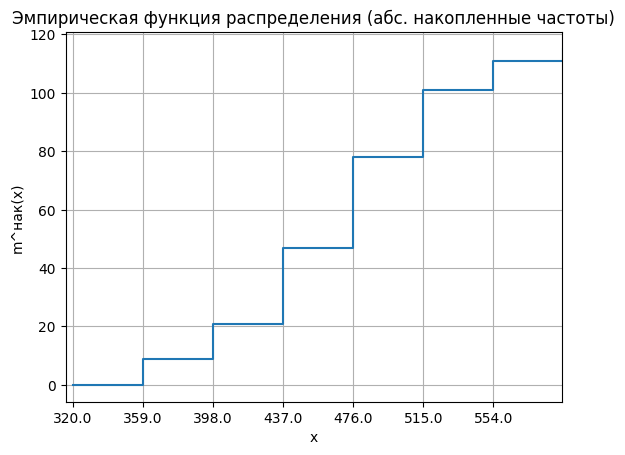

In [58]:
x_step = edges
y_step = np.concatenate(([0], cum_abs))

plt.figure()
plt.step(x_step, y_step, where='post')
plt.xticks(x_step, [f'{x:.1f}' for x in x_step])

plt.title('Эмпирическая функция распределения (абс. накопленные частоты)')
plt.xlabel("x")
plt.ylabel("m^нак(x)")
plt.ylim(-0.05 * n, 1.05 * n)
plt.xlim(edges[0] - 4, edges[-1] - 1)
plt.grid()
plt.show()

Краткая интерпретация (абсолютные частоты):  
- По гистограмме/полигону видно, в каких интервалах сосредоточено больше всего наблюдений.  
- По эмпирической функции видно, как быстро накапливается число наблюдений при росте \(x\) (ступенчатый график).


### 6) То же для относительных частот и сравнение

Для относительных частот:  
- Полигон строится по $(x\tilde{}_i, m\tilde{}_i)$.  
- Гистограмма строится так, чтобы сумма высот по интервалам давала 1 (используем веса $1/n$).  
- Эмпирическая функция распределения — нормированная (0…1), по сути это и есть $F_n(x)$.


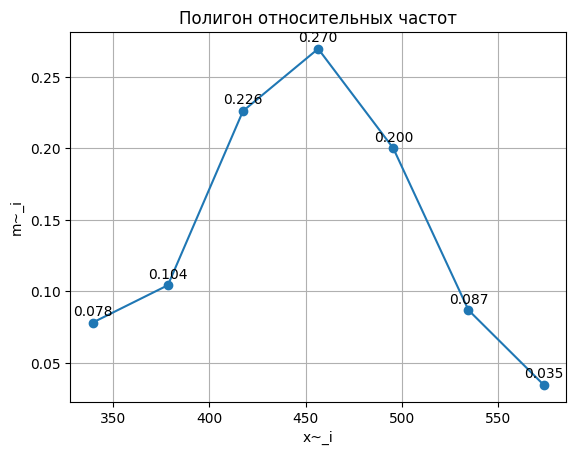

In [64]:
plt.figure()
plt.plot(midpoints, rel_hist, marker="o")
for i, txt in enumerate(rel_hist):
    plt.annotate(f'{txt:.3f}', (midpoints[i], rel_hist[i]), textcoords="offset points", xytext=(0,5), ha='center')
plt.title("Полигон относительных частот")
plt.xlabel("x~_i")
plt.ylabel("m~_i")
plt.grid(True)
plt.show()

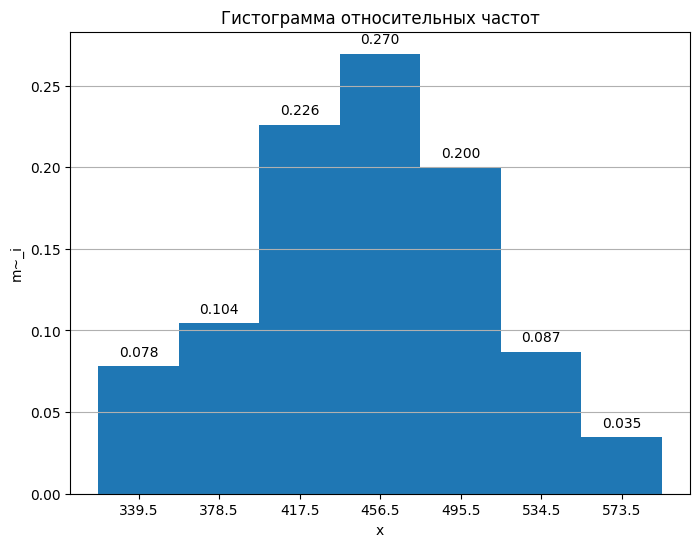

In [73]:
plt.figure(figsize=(8, 6))
counts, bins, patches = plt.hist(x_sorted, bins=edges, weights=np.ones(n) / n)
plt.title("Гистограмма относительных частот")
plt.xlabel("x")
plt.ylabel("m~_i")
plt.grid(axis='y')

for count, patch in zip(counts, patches):
    if count > 0:
        x_coord = patch.get_x() + patch.get_width() / 2
        y_coord = patch.get_height()
        plt.annotate(f'{count:.3f}', xy=(x_coord, y_coord), textcoords="offset points", xytext=(0,5), ha='center', va='bottom')

plt.xticks(midpoints, [f'{x:.1f}' for x in midpoints])

plt.show()

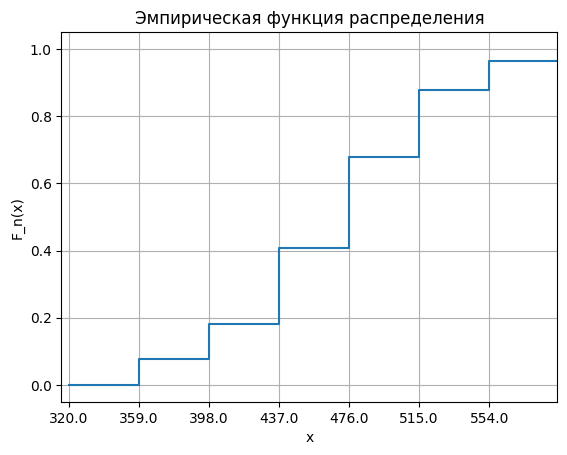

In [59]:
x_step = edges
y_step = np.concatenate(([0.0], cum_rel))

plt.figure()
plt.step(x_step, y_step, where='post')
plt.xticks(x_step, [f'{x:.1f}' for x in x_step])

plt.title('Эмпирическая функция распределения')
plt.xlabel("x")
plt.ylabel("F_n(x)")
plt.ylim(-0.05, 1.05)
plt.xlim(edges[0] - 4, edges[-1] - 1)
plt.grid()
plt.show()

Абсолютные частоты и их графические представления (полигоны, гистограммы) дают прямое представление о численности наблюдений в каждом интервале. В то время как относительные частоты и их графики, включая эмпирическую функцию распределения, служат для вероятностной интерпретации, сравнения распределений различных выборок и более глубокого анализа формы распределения, поскольку они не зависят от общего объема выборки.

### Выводы


## Выводы

В ходе выполнения практической работы была проведена статистическая обработка одномерной выборки данных об объемном весе (ν, г/см³) резонансной ели, объемом **115** наблюдений. Были сформированы ранжированный, вариационный и интервальный ряды распределения, рассчитаны абсолютные, относительные и накопленные частоты. С использованием формулы Стерджесса определено оптимальное число интервалов и выполнена группировка исходных данных.

По полученным результатам были построены гистограммы, полигоны абсолютных и относительных частот, а также эмпирические функции распределения для обоих типов частот.